In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [5]:
movies = pd.read_csv("C:\\Users\\sanch\\Downloads\\tmdb_5000_movies.csv")
credits = pd.read_csv("C:\\Users\\sanch\\Downloads\\tmdb_5000_credits.csv")

In [6]:
movies = movies.merge(credits,on='title')

In [8]:
movies.isnull().sum()

budget                     0
genres                     0
homepage                3096
id                         0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
movie_id                   0
cast                       0
crew                       0
dtype: int64

In [9]:
movies.dropna(inplace=True)

In [10]:
movies.isnull().sum()

budget                  0
genres                  0
homepage                0
id                      0
keywords                0
original_language       0
original_title          0
overview                0
popularity              0
production_companies    0
production_countries    0
release_date            0
revenue                 0
runtime                 0
spoken_languages        0
status                  0
tagline                 0
title                   0
vote_average            0
vote_count              0
movie_id                0
cast                    0
crew                    0
dtype: int64

In [11]:
movies.duplicated().sum()

np.int64(0)

#### RATING DISTRIBUTION

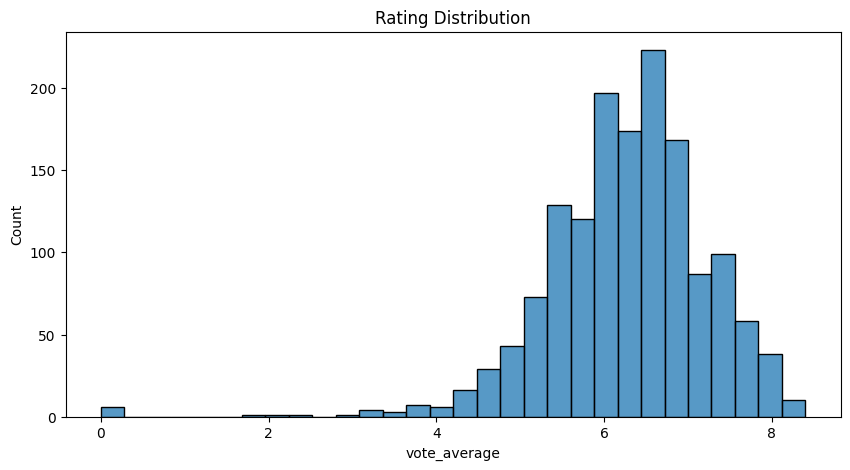

In [12]:
plt.figure(figsize=(10,5))
sns.histplot(movies['vote_average'], bins=30)
plt.title("Rating Distribution")
plt.show()

#### MOST POPULAR MOVIES

In [13]:
top_movies = movies.sort_values('popularity', ascending=False).head(10)

<Axes: xlabel='popularity', ylabel='title'>

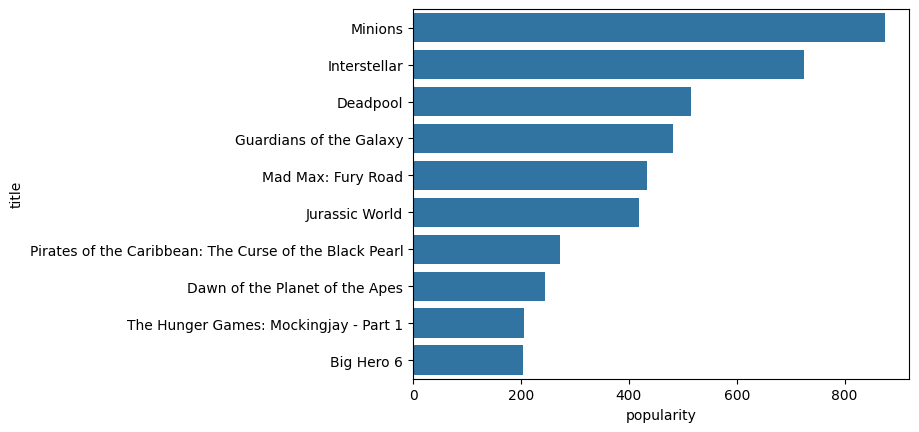

In [14]:
sns.barplot(x=top_movies['popularity'],
            y=top_movies['title'])

#### RELEASE YEAR TREND

In [15]:
movies['release_year'] = pd.to_datetime(
    movies['release_date']
).dt.year

In [16]:
yearly_movies = movies['release_year'].value_counts().sort_index()

<Axes: xlabel='release_year'>

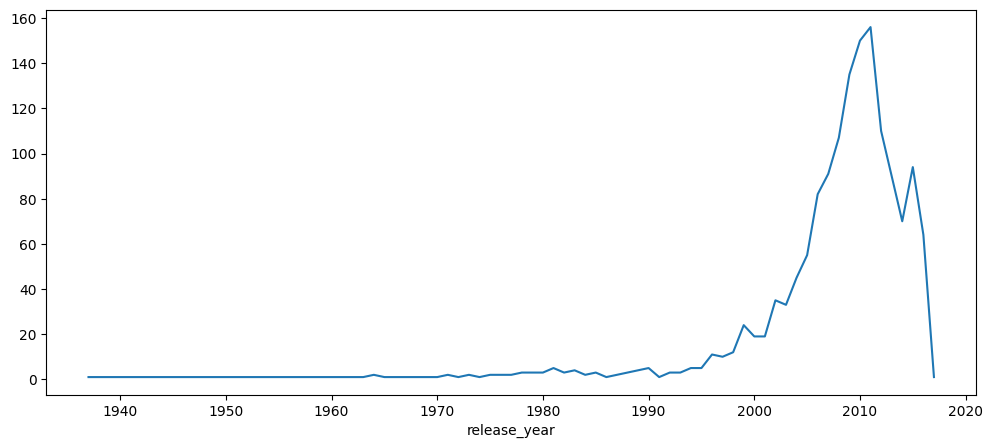

In [17]:
yearly_movies.plot(figsize=(12,5))

#### CORRELATION HEATMAP

In [18]:
corr = movies[['vote_average',
               'vote_count',
               'popularity']].corr()

<Axes: >

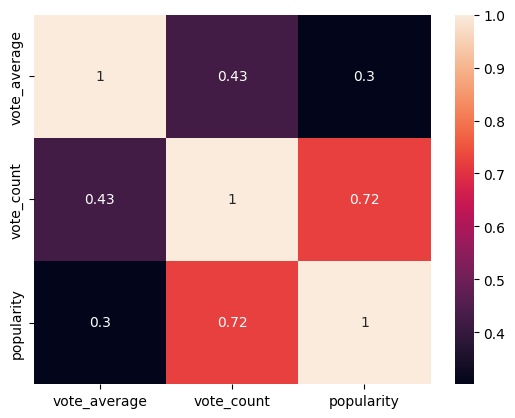

In [19]:
sns.heatmap(corr, annot=True)

#### TOP DIRECTORS